In [1]:
!pip install numpy pandas matplotlib scikit-learn tensorflow keras opencv-python opencv-python-headless


In [2]:
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
base_dir = '/content/drive/MyDrive/ML Lab/ML Final Project/Dataset'


In [12]:
data_dir = "/content/drive/MyDrive/ML Lab/ML Final Project/Dataset"  # Change this to your dataset path
categories = os.listdir(data_dir)
print("Categories:", categories)


Categories: ['Car', 'Truck', 'Bus', 'motorcycle']


In [13]:
IMG_SIZE = 128
data = []
labels = []

for category in categories:
    path = os.path.join(data_dir, category)
    label = categories.index(category)  # Assign numeric labels to categories
    for img in os.listdir(path):
        try:
            img_path = os.path.join(path, img)
            image = cv2.imread(img_path)
            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))  # Resize images
            data.append(image)
            labels.append(label)
        except Exception as e:
            pass

data = np.array(data) / 255.0  # Normalize pixel values
labels = np.array(labels)
print("Data shape:", data.shape)
print("Labels shape:", labels.shape)


Data shape: (400, 128, 128, 3)
Labels shape: (400,)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)


In [15]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)


In [16]:
svm = SVC(kernel='linear')
svm.fit(X_train_flat, y_train)


SVC(kernel='linear')

In [17]:
predictions = svm.predict(X_test_flat)
print(classification_report(y_test, predictions))


              precision    recall  f1-score   support

           0       0.52      0.54      0.53        26
           1       0.47      0.39      0.42        18
           2       0.45      0.50      0.47        18
           3       0.56      0.56      0.56        18

    accuracy                           0.50        80
   macro avg       0.50      0.50      0.50        80
weighted avg       0.50      0.50      0.50        80



In [18]:
y_train_onehot = to_categorical(y_train, num_classes=len(categories))
y_test_onehot = to_categorical(y_test, num_classes=len(categories))


In [19]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(categories), activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
history = model.fit(X_train, y_train_onehot, validation_split=0.2, epochs=10, batch_size=32)


Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.2697 - loss: 1.9807 - val_accuracy: 0.2344 - val_loss: 1.3898
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.3628 - loss: 1.3589 - val_accuracy: 0.3438 - val_loss: 1.3337
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.5053 - loss: 1.2120 - val_accuracy: 0.4531 - val_loss: 1.2674
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.6131 - loss: 0.9985 - val_accuracy: 0.5469 - val_loss: 1.1447
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 793ms/step - accuracy: 0.7410 - loss: 0.7782 - val_accuracy: 0.5938 - val_loss: 1.1241
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 953ms/step - accuracy: 0.7665 - loss: 0.6561 - val_accuracy: 0.5469 - val_loss: 1.1106
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 913ms/step - accuracy: 0.8822 - loss: 0.3993 - val_accuracy: 0.6406 - val_loss: 1.0186
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 839ms/step - accuracy: 0.9596 - loss: 0.1946 - val_accuracy: 0.6094 - val_loss: 1.020

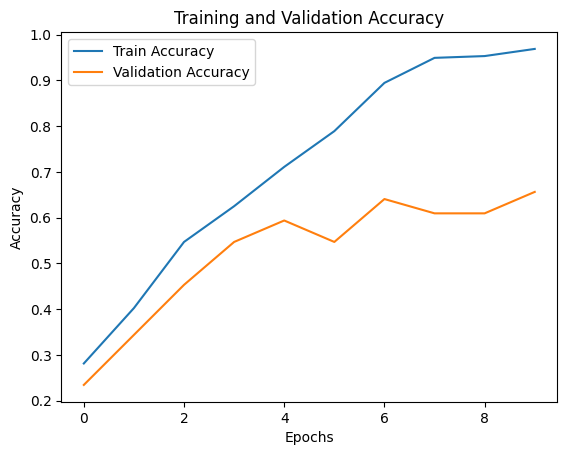

In [23]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.show()


In [47]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_onehot, verbose=1)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 150ms/step - accuracy: 0.5539 - loss: 1.3471
Test Accuracy: 53.75%


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step


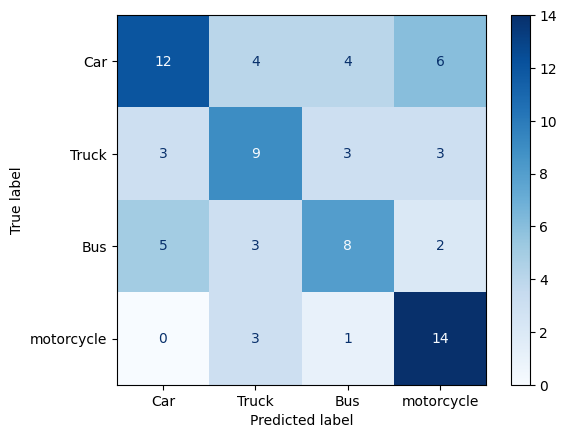

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(X_test), axis=1)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=categories)
disp.plot(cmap=plt.cm.Blues)
plt.show()


In [26]:
custom_img_path = "path_to_custom_image.jpg"  # Replace with the actual path to your image
custom_image = cv2.imread(custom_img_path)

# Check if image was loaded successfully
if custom_image is None:
    print(f"Error: Could not load image from {custom_img_path}. Please check the path and file.")
else:
    custom_image = cv2.resize(custom_image, (IMG_SIZE, IMG_SIZE)) / 255.0
    custom_image = np.expand_dims(custom_image, axis=0)  # Add batch dimension

    prediction = model.predict(custom_image)
    predicted_class = categories[np.argmax(prediction)]
    print(f"The predicted class is: {predicted_class}")



Error: Could not load image from path_to_custom_image.jpg. Please check the path and file.


In [27]:
model.save("vehicle_classification_model.h5")


In [28]:
from tensorflow.keras.models import load_model

loaded_model = load_model("vehicle_classification_model.h5")


In [30]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)
datagen.fit(X_train)


In [32]:
for img_file in os.listdir("/content/drive/MyDrive/ML Lab/ML Final Project/Testdataset"):
    img_path = os.path.join("/content/drive/MyDrive/ML Lab/ML Final Project/Testdataset", img_file)
    image = cv2.imread(img_path)
    image_resized = cv2.resize(image, (IMG_SIZE, IMG_SIZE)) / 255.0
    image_resized = np.expand_dims(image_resized, axis=0)

    prediction = model.predict(image_resized)
    predicted_class = categories[np.argmax(prediction)]
    print(f"{img_file} is classified as {predicted_class}")




1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
motor1.jpg is classified as motorcycle
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
truck1.jpeg is classified as Truck


In [34]:
from tensorflow.keras.models import load_model

# Load the model
model = load_model("vehicle_classifier_cnn.h5")

# Use it for predictions as before


In [35]:
from tensorflow.keras.models import load_model

# Load the trained model
model = load_model("vehicle_classifier_cnn.h5")
print("Model loaded successfully!")


Model loaded successfully!


In [44]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)



3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - accuracy: 0.5539 - loss: 1.3471
Test Accuracy: 53.75%


In [48]:
model.save("vehicle_classifier_model.h5")
print("Model saved as vehicle_classifier_model.h5")




Model saved as vehicle_classifier_model.h5
